# Kilter Grade Prediction — Model Training and Evaluation

This notebook trains and evaluates three regression models for Kilter Board climbs. The target is the continuous variable `difficulty_average` : a community consensus on the climb's difficulty. The regression models trained and evaluated are
- A Regularized Linear Regression (Ridge) model
- A Decision Tree model
- A Gradient boosed decision tree model : XGBoost

The target is noisy: climbers can reasonably disagree by about one or two grade step. While the training score is the *negative mean absolute error*, we therefore also report proportion of climbs whose rounded prediction is within ±1 or ±2 grade steps of the rounded true value.


In [1]:
from pathlib import Path
import sys
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import loguniform, randint
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

TRAIN_CSV = PROJECT_ROOT / "data" / "processed" / "data_processed_train.csv"
TEST_CSV = PROJECT_ROOT / "data" / "processed" / "data_processed_test.csv"
MODEL_DIR = PROJECT_ROOT / "models" / "saved_models"
RESULTS_DIR = PROJECT_ROOT / "models" / "results"
MODEL_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)


RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)
pd.set_option("display.max_columns", 50)
plt.rcParams["figure.figsize"] = (8, 4.5)

## 1. Models training

`feature_engineering.py` writes `data_processed_train.csv` and `data_processed_test.csv`; these are the exact files used here. 

We remove the feature `ascenscionist_counts` from the predictive features list: popularity or the number of ascents should not impact the difficulty. It is nevertheless used to create sample weights as it is an indicator of the quality of the community grade.

In [2]:
TARGET = "difficulty_average"
NON_FEATURE_COLS = [TARGET, "ascensionist_count"]

def make_sample_weights(df, max_ascent_cap=100):
    if "ascensionist_count" not in df.columns:
        raise ValueError("ascensionist_count is required for the supplied sample-weight definition")
    w = np.sqrt(df["ascensionist_count"].clip(upper=max_ascent_cap))
    w = w / w.min()
    return w.to_numpy(dtype=np.float32)


def load_data(path, verbose=True):
    df = pd.read_csv(path)
    if TARGET not in df.columns:
        raise ValueError(f"Target column {TARGET!r} not found in {path}")
    y = df[TARGET].astype(float)
    X = df.drop(columns=[c for c in NON_FEATURE_COLS if c in df.columns])
    X = X.apply(pd.to_numeric, errors="coerce").fillna(0)
    weights = make_sample_weights(df)
    if verbose:
        print(f"target mean={y.mean():.2f}, std={y.std():.2f}, range=[{y.min():.2f}, {y.max():.2f}]")
    return X, y, weights

X_train, y_train, w_train = load_data(TRAIN_CSV)
X_test, y_test, w_test = load_data(TEST_CSV)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
print("Train/test shapes:", X_train.shape, X_test.shape)
print("Target:", TARGET)
print("Missing values after coercion:", int(X_train.isna().sum().sum()), int(X_test.isna().sum().sum()))
assert list(X_train.columns) == list(X_test.columns)
assert len(X_train) == len(y_train) and len(X_test) == len(y_test)

target mean=21.54, std=3.16, range=[15.00, 27.00]
target mean=21.43, std=3.24, range=[15.00, 27.00]
Train/test shapes: (10364, 921) (1152, 921)
Target: difficulty_average
Missing values after coercion: 0 0


The hyperparameter search uses 20 random configurations for each estimator and three-fold cross-validation (60 fits per model).

Final evaluation is performed on both the training and test datasets. Predictions are rounded and clipped to the observed split range (15–27), and the rounded true values are compared with them. within_1 is the fraction within ±1 grade step, and within_2 is the fraction within ±2 steps.

In [3]:
CONFIG = {
    "random_state": RANDOM_STATE,
    "n_iter": 20,
    "cv": 3, #cross validation
    "scoring": "neg_mean_absolute_error",
    "n_jobs": 2,
    "pre_dispatch": 4,
}


def save_bundle(model, filename):
    path = MODEL_DIR / filename
    joblib.dump({"model": model, "features": list(X_train.columns), "target": TARGET}, path)
    return path

def run_search(estimator, param_dist):
    search = RandomizedSearchCV(
        estimator, param_distributions=param_dist, n_iter=CONFIG["n_iter"],
        cv=CONFIG["cv"], scoring=CONFIG["scoring"],
        random_state=RANDOM_STATE, n_jobs=CONFIG["n_jobs"],
        pre_dispatch=CONFIG["pre_dispatch"], verbose=1, refit=True,
    )
    search.fit(X_train, y_train, sample_weight=w_train)
    print(f"Best CV MAE: {-search.best_score_:.3f}")
    print("Best params:", search.best_params_)
    return search


def evaluate_model(model, name):
    pred_train = model.predict(X_train)
    pred_test = model.predict(X_test)
    rows = []
    for split, y_true, pred in [("train", y_train, pred_train), ("test", y_test, pred_test)]:
        y_pred_r = np.clip(np.round(pred), y_true.min(), y_true.max())
        y_true_r = np.round(y_true)
        rows.append({
            "model": name, "split": split,
            "MAE": mean_absolute_error(y_true, pred),
            "RMSE": mean_squared_error(y_true, pred),
            "R2": r2_score(y_true, pred),
            "within_1": (np.abs(y_pred_r - y_true_r) <= 1).mean(),
            "within_2": (np.abs(y_pred_r - y_true_r) <= 2).mean(),
        })
    return pd.DataFrame(rows), {"train": pred_train, "test": pred_test}



### Ridge regression

The search samples alpha log-uniformly from 1e-4 to 1e3 and tries five solvers (cholesky, lsqr, sparse_cg, sag, and saga). 


In [4]:
lr_param_dist = {
    "alpha": loguniform(1e-4, 1e3),
    "solver": ["cholesky", "lsqr", "sparse_cg", "sag", "saga"],
}
lr_search = run_search(Ridge(random_state=RANDOM_STATE), lr_param_dist)
lr_model = Ridge(**lr_search.best_params_, random_state=RANDOM_STATE)
lr_model.fit(X_train, y_train, sample_weight=w_train)
lr_path = save_bundle(lr_model, "LR_model.joblib")

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best CV MAE: 1.366
Best params: {'alpha': np.float64(0.0001450230301963137), 'solver': 'sparse_cg'}


### Decision-Tree regression

The randomized search samples max_depth (2–63), min_samples_split (2–199), min_samples_leaf (1–99), max_features (all features, square-root, log2, 0.5, or 0.7), and ccp_alpha from 1e-5 to 1e-1.

In [5]:
dt_param_dist = {
    "max_depth": randint(2, 64),
    "min_samples_split": randint(2, 200),
    "min_samples_leaf": randint(1, 100),
    "max_features": [None, "sqrt", "log2", 0.5, 0.7],
    "ccp_alpha": loguniform(1e-5, 1e-1),
}
dt_search = run_search(DecisionTreeRegressor(random_state=RANDOM_STATE), dt_param_dist)
dt_model = DecisionTreeRegressor(**dt_search.best_params_, random_state=RANDOM_STATE)
dt_model.fit(X_train, y_train, sample_weight=w_train)
dt_path = save_bundle(dt_model, "DT_model.joblib")

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best CV MAE: 1.974
Best params: {'ccp_alpha': np.float64(0.00010842262717330161), 'max_depth': 41, 'max_features': 0.5, 'min_samples_leaf': 2, 'min_samples_split': 135}


### XGBoost regression

The randomized search samples over tree count, learning rate, depth, minimum child weight, row subsampling, column subsampling, and `reg_alpha`/`reg_lambda`. After selecting the best search configuration, we increase `n_estimators` with 5,000 and and use a random 10% split of the training partition as an internal validation set. 

In [6]:
def run_search(estimator, param_dist):
    search = RandomizedSearchCV(
        estimator, param_distributions=param_dist, n_iter=CONFIG["n_iter"],
        cv=CONFIG["cv"], scoring=CONFIG["scoring"],
        random_state=RANDOM_STATE, n_jobs=CONFIG["n_jobs"],
        pre_dispatch=CONFIG["pre_dispatch"], verbose=1, refit=True,
    )
    search.fit(X_train, y_train, sample_weight=w_train)
    print(f"Best CV MAE: {-search.best_score_:.3f}")
    print("Best params:", search.best_params_)
    return search

xgb_param_dist = {
    "n_estimators": randint(200, 1500),
    "learning_rate": loguniform(0.02, 0.2),
    "max_depth": randint(3, 10),
    "min_child_weight": randint(1, 20),
    "subsample": [0.5, 0.7, 0.9, 1.0],
    "colsample_bytree": [0.5, 0.7, 0.9, 1.0],
    "reg_alpha": loguniform(1e-3, 10.0),
    "reg_lambda": loguniform(1e-3, 10.0),
}
xgb_search = run_search(XGBRegressor(random_state=RANDOM_STATE, n_jobs=1), xgb_param_dist)

X_tr, X_val, y_tr, y_val, w_tr, _ = train_test_split(
    X_train, y_train, w_train, test_size=0.1, random_state=RANDOM_STATE
)
xgb_best = xgb_search.best_params_.copy()
xgb_best.update({
    "n_estimators": 5000,  # Increase for final model
    "early_stopping_rounds": 50,  # Stop if no improvement for 50 rounds
    "n_jobs": -1,  # Use all CPU cores
    "random_state": RANDOM_STATE,
})
xgb_model = XGBRegressor(**xgb_best)
xgb_model.fit(X_tr, y_tr, sample_weight=w_tr, eval_set=[(X_val, y_val)], verbose=False)
xgb_path = save_bundle(xgb_model, "XGB_model.joblib")

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best CV MAE: 1.332
Best params: {'colsample_bytree': 0.7, 'learning_rate': np.float64(0.0623484400600926), 'max_depth': 3, 'min_child_weight': 15, 'n_estimators': 1238, 'reg_alpha': np.float64(0.0027769194556163876), 'reg_lambda': np.float64(0.05719341217670732), 'subsample': 0.9}


## 2. Performance evaluation

The table belows gives performance scores for every model. We recall that
- **MAE:** Mean absolute error 
- **within_1:** proportion of climbs whose rounded prediction is within one grade step from the rounded target.
- **within_2:** idem for two grade step

In [7]:
metric_frames = []
predictions = {}
searches = {
    "Linear Regression (Ridge)": lr_search,
    "Decision Tree": dt_search,
    "XGBoost": xgb_search,
}
for name, model in [("XGBoost", xgb_model), ("Linear Regression (Ridge)", lr_model), ("Decision Tree", dt_model)]:
    metrics, preds = evaluate_model(model, name)
    metrics["CV_MAE"] = -searches[name].best_score_
    metric_frames.append(metrics)
    predictions[name] = preds
metrics_table = pd.concat(metric_frames, ignore_index=True)
metrics_table.to_csv(RESULTS_DIR / "model_metrics.csv", index=False)

metrics_wide = metrics_table.pivot(index="model", columns="split", values=["MAE", "within_1", "within_2"])
display(metrics_wide.round(3))


MAE        within_1        within_2       
split                       test  train     test  train     test  train
model                                                                  
Decision Tree              1.940  1.657    0.472  0.538    0.711  0.771
Linear Regression (Ridge)  1.382  1.347    0.624  0.626    0.838  0.856
XGBoost                    1.276  0.928    0.654  0.793    0.865  0.953

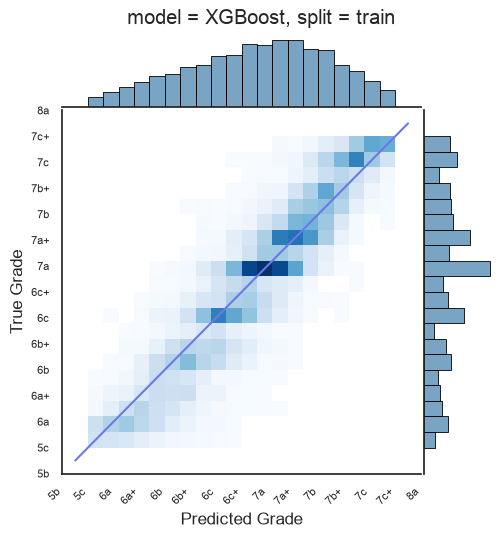

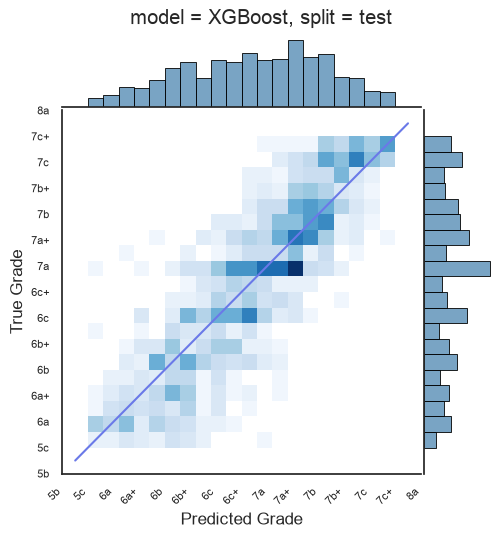

In [24]:
def grade_ticks(vmin, vmax, step=1):
    """Return (tick_positions, tick_labels) for the grade axis."""
    lo, hi = int(np.floor(vmin)), int(np.ceil(vmax))
    ticks = list(range(lo, hi + 1, step))
    labels = [DIFFICULTY_TO_GRADE.get(t, str(t)) for t in ticks]
    return ticks, labels
    
# display_difficulty (int) -> French boulder grade (BoardLib difficulty_grades table)
DIFFICULTY_TO_GRADE = {
    10: "4a",  11: "4b",  12: "4c",  13: "5a",  14: "5b",  15: "5c",
    16: "6a",  17: "6a+", 18: "6b",  19: "6b+", 20: "6c",  21: "6c+",
    22: "7a",  23: "7a+", 24: "7b",  25: "7b+", 26: "7c",  27: "7c+",
    28: "8a",  29: "8a+", 30: "8b",  31: "8b+", 32: "8c",  33: "8c+",
    34: "9a",  35: "9a+", 36: "9b",  37: "9b+", 38: "9c",
} 
def plot_pred_vs_true(y_true, y_pred, out_path, title=None, subtitle=None,
                      bins=20, show=False):
    """
    Seaborn jointplot: 2D histogram of (predicted, true) grades
    + marginal histograms + identity line, with grade tick labels.
    """
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    # Clip predictions to the range of true values 
    y_pred = np.clip(y_pred, y_true.min(), y_true.max())

    lo = min(y_true.min(), y_pred.min()) - 0.5
    hi = max(y_true.max(), y_pred.max()) + 0.5

    sns.set_theme(style="white", font_scale=1.0)

    g = sns.jointplot(
        x=y_pred, y=y_true,
        kind="hist", bins=bins, color="#4C86B0",
        height=5, ratio=5, space=0.05,
        marginal_kws=dict(bins=bins, edgecolor="black", linewidth=0.6),
        joint_kws=dict(cmap="Blues"),
    )

    g.ax_joint.plot([lo, hi], [lo, hi], color="#6A79E8", lw=1.5, zorder=5)
    g.ax_joint.set_xlim(lo, hi)
    g.ax_joint.set_ylim(lo, hi)

    ticks, labels = grade_ticks(lo, hi, step=1)
    g.ax_joint.set_xticks(ticks)
    g.ax_joint.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
    g.ax_joint.set_yticks(ticks)
    g.ax_joint.set_yticklabels(labels, fontsize=8)

    g.ax_joint.set_xlabel("Predicted Grade")
    g.ax_joint.set_ylabel("True Grade")

    if title and subtitle:
        g.figure.suptitle(f"{title}\n{subtitle}", y=1.06)
    elif title:
        g.figure.suptitle(title, y=1.02)

    plt.show()
    plt.close(g.figure)
    return g

plot_pred_vs_true(y_train, predictions["XGBoost"]["train"], "train", title=f"model = {"XGBoost"}, split = train")
plot_pred_vs_true(y_test, predictions["XGBoost"]["test"], "test", title=f"model = {"XGBoost"}, split = test")


XGBoost is best on all scores and achieves 65.4% of rounded predictions are within one step. However it only beats the linear model (Ridge) by ~3% (or ~0.1 in MAE). This suggest that the gains from nonlinearity are small, and the ceiling is in the features.

A ~1.3 grade average error is arguably near the practical limit, given the noise on a consensus grade and the inputs of this dataset. Richer inputs would likely add more gains than better models. For instance we could add hold shapes and body-position features, use a CNN on the rendered board image, or ultimately rely on ascent videos to capture the actual sequence of moves.


## Feature importances

We now estimates importances of each features for XGBoost model. For each feature, we randomly shuffle - or permute - its values such that the feature does no longer provide meaningful information.
Then we measures the resulting change in the negative-MAE score over 10 repeats. Larger positive values indicate more importance of the feature.



Computing permutation importance (10 repeats)...

Top 20 features:
avg_move_dist                   0.563666
avg_consecutive_move_x_angle    0.186792
hold_density                    0.175761
std_consecutive_move            0.117120
move_dist_x_angle               0.087000
angle                           0.063835
hold_1302_hand                  0.055802
max_move_dist                   0.052089
hold_1234_hand                  0.044929
hold_1300_hand                  0.032109
hold_1353_hand                  0.031560
avg_consecutive_move            0.029735
hold_1257_hand                  0.024595
hold_1163_start                 0.022397
n_holds                         0.022158
is_nomatch                      0.020436
hand_foot_dist                  0.016059
hold_1352_hand                  0.015756
hold_1320_hand                  0.015348
board_height                    0.014711


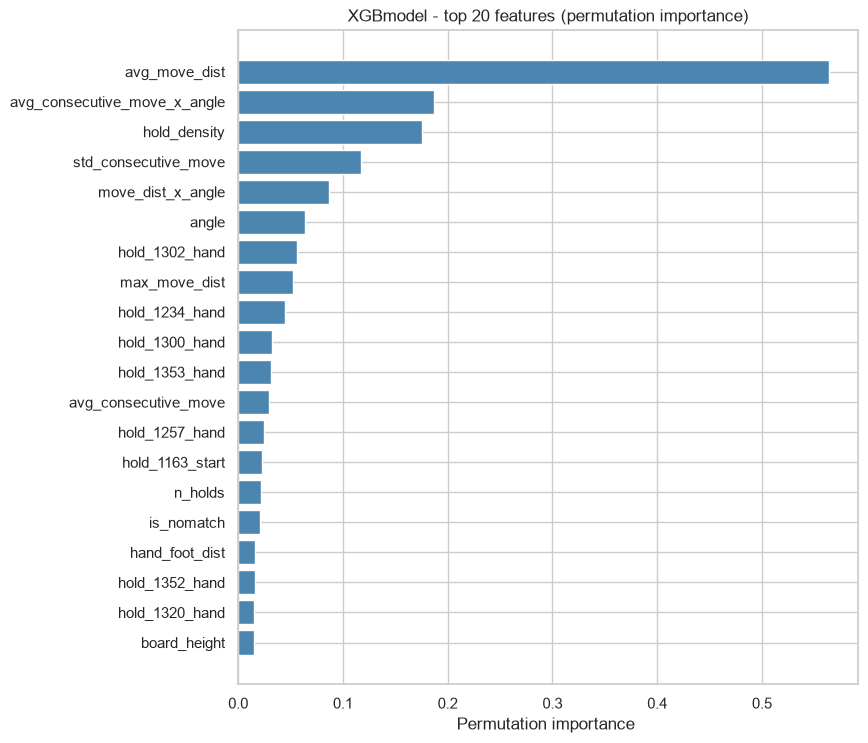

angle              0.063835
n_holds            0.022158
is_nomatch         0.020436
n_hand            -0.000357
n_foot             0.001487
                     ...   
hold_1274_start    0.000000
hold_1276_start    0.000000
hold_1495_start    0.000000
hold_1281_start    0.000000
hold_4704_start    0.000000
Length: 921, dtype: float64

In [9]:
def align_features(X, features):
    """Reorder / complete columns so they match the training feature set."""
    if features is None:
        return X
    return X.reindex(columns=list(features), fill_value=0)

def plot_feature_importance(importances, top_n=20, title=None):
    """Horizontal bar plot of the top-N permutation importances."""
    imp = importances.sort_values(ascending=False).head(top_n)[::-1]

    sns.set_theme(style="whitegrid", font_scale=1.0)
    fig, ax = plt.subplots(figsize=(8, 0.35 * len(imp) + 1.5))
    ax.barh(imp.index, imp.values, color="#4C86B0")
    ax.set_xlabel("Permutation importance ")
    if title:
        ax.set_title(title)

    plt.show()
    plt.close(fig)

def compute_feature_importance(model, X, y, model_name,
                               n_repeats=10, top_n=20,
                               random_state=RANDOM_STATE, show=False):
    """Permutation importance on the test set + bar plot + CSV export."""
    print(f"\nComputing permutation importance ({n_repeats} repeats)...")
    result = permutation_importance(
        model, X, y,
        n_repeats=n_repeats,
        random_state=random_state,
        scoring="neg_mean_absolute_error",
        n_jobs=-1,
    )
    imp = pd.Series(result.importances_mean, index=X.columns)
    imp_std = pd.Series(result.importances_std, index=X.columns)

    print(f"\nTop {top_n} features:")
    print(imp.sort_values(ascending=False).head(top_n).to_string())

    plot_feature_importance(
        imp,
        top_n=top_n,
        title=f"{model_name} - top {top_n} features (permutation importance)",
    )
    return imp

compute_feature_importance(xgb_model, X_test, y_test, "XGBmodel",
                               n_repeats=10, top_n=20,
                               random_state=RANDOM_STATE, show=False)


The ranking emphasises geometric features: average move distance, angle-adjusted consecutive movement, hold density... We also spot some holds that appear to have a rather large impact on the difficulty. For instance, the hold with placement_id = 1302 is ranked 7th, and visualising it confirms that it is a jug — namely a very good and easy-to-hold. 

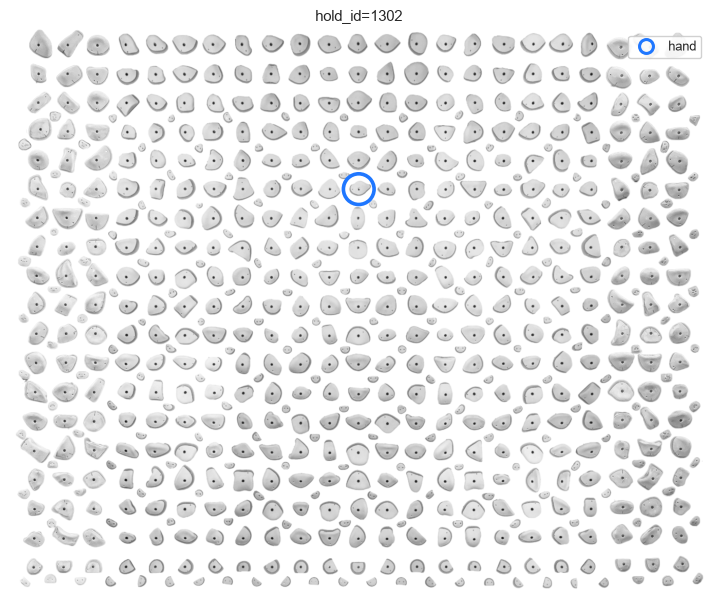

<Axes: title={'center': 'hold_id=1302'}>

In [10]:
from utils.board_visuals import plot_climb
hold1302 = [(1302,72,112,'hand')]
plot_climb(
    hold1302,
    title="hold_id=1302",
)